# 01 · Huấn luyện cấu hình gốc

Một lượt chạy end-to-end với cấu hình nền: `transpose` + `full skip` +
`BCE+Dice`. Mọi thí nghiệm sau đều so với cấu hình này.

Người phụ trách: **SV A**.

In [1]:
# Chạy được cả trên Colab lẫn máy cá nhân
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("unet-kvasir").exists():
    # !git clone <repo cua nhom> unet-kvasir
    pass
ROOT = Path("unet-kvasir") if Path("unet-kvasir").exists() else Path("..")
os.chdir(ROOT.resolve())
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from src import *
print("Thư mục làm việc:", Path.cwd())
print("Thiết bị:", get_device())

Thư mục làm việc: /root/workspace/unet-kvasir
Thiết bị: cuda


In [2]:
cfg = Config(
    loss_name="bce_dice",
    up_mode="transpose",
    skip_mode="full",
    epochs=120,
    batch_size=8,
    seed=42,
)
print("run_id:", cfg.run_id)

run_id: bce_dice-transpose-full-s42-c6245d


Nếu Colab báo hết VRAM, hạ `base_channels=32` hoặc `batch_size=4`.
Nhớ ghi lại thay đổi đó trong báo cáo vì nó ảnh hưởng tới mọi so sánh.

In [3]:
result = run_experiment(cfg, skip_if_logged=False)

=== bce_dice-transpose-full-s42-c6245d === 31,037,633 tham số, thiết bị cuda
epoch   1/120 | train 0.6585 | val 0.5408 | val dice 0.2929 | val iou 0.1946 *
epoch   2/120 | train 0.5593 | val 0.6215 | val dice 0.1405 | val iou 0.0857
epoch   3/120 | train 0.5228 | val 0.5411 | val dice 0.3076 | val iou 0.2007 *
epoch   4/120 | train 0.5107 | val 0.4704 | val dice 0.5351 | val iou 0.3955 *
epoch   5/120 | train 0.5004 | val 0.4682 | val dice 0.4998 | val iou 0.3609
epoch   6/120 | train 0.4896 | val 0.4514 | val dice 0.5287 | val iou 0.3871
epoch   7/120 | train 0.4884 | val 0.4879 | val dice 0.5216 | val iou 0.3848
epoch   8/120 | train 0.4767 | val 0.4697 | val dice 0.4632 | val iou 0.3415
epoch   9/120 | train 0.4663 | val 0.4968 | val dice 0.3635 | val iou 0.2629
epoch  10/120 | train 0.4626 | val 0.4607 | val dice 0.4733 | val iou 0.3450
epoch  11/120 | train 0.4569 | val 0.4432 | val dice 0.5408 | val iou 0.4054 *
epoch  12/120 | train 0.4575 | val 0.4336 | val dice 0.5200 | val io

## Đường cong huấn luyện

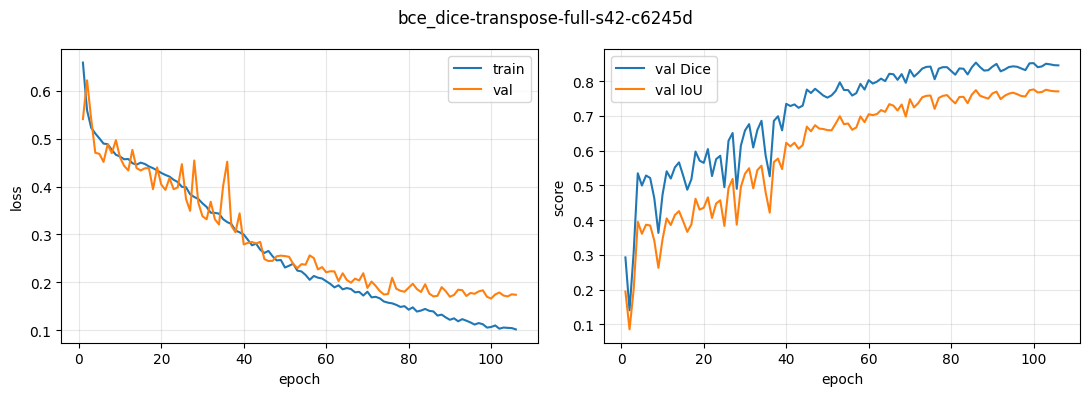

In [4]:
from src.viz import plot_history

if not result.get("history"):
    print("Không có history trên đĩa (lượt này chạy bằng bản code cũ).\n"
          "Chạy lại với skip_if_logged=False nếu cần đường cong.")
else:
    fig = plot_history(result["history"], title=cfg.run_id,
                       save_path=f"{cfg.fig_dir}/history_{cfg.run_id}.png")

## Đọc gì từ hình này

- `train_loss` giảm nhưng `val_loss` tăng dần từ một epoch nào đó → quá khớp.
- `val_dice` dao động mạnh giữa các epoch → learning rate còn cao.
- `val_dice` phẳng ngay từ đầu → nghi ngờ lỗi dữ liệu, kiểm lại notebook 00.

## Xem thử dự đoán

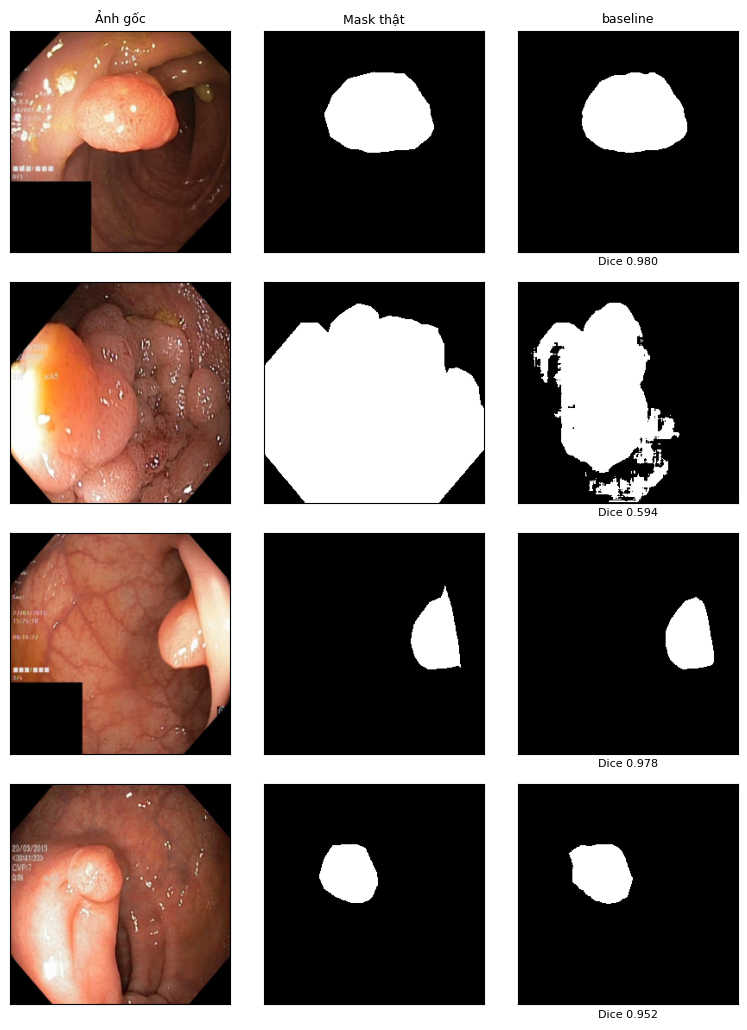

In [5]:
from src.viz import comparison_grid

# run_experiment trả về model ở cả hai nhánh (chạy mới và bỏ qua), nhưng nếu
# checkpoint đã bị xoá thì model là None — nạp lại cho chắc.
model = result.get("model")
if model is None:
    model = load_best(build_model(cfg), cfg.ckpt_path, get_device())

splits = load_splits(cfg.split_dir)
test_ds = KvasirSegDataset(cfg.data_root, splits["test"],
                           SegTransform(cfg.image_size, train=False))
fig = comparison_grid(test_ds, {"baseline": model},
                      indices=range(4), device=get_device())